In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Go from notebooks/ to the project root
project_root = Path.cwd().parent

monday_path = (
    project_root
    / "data"
    / "raw"
    / "traffic_labels"
    / "Monday-WorkingHours.pcap_ISCX.csv.parquet"
)

portscan_path = (
    project_root
    / "data"
    / "raw"
    / "traffic_labels"
    / "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv.parquet"
)

# Check that the files actually exist
print("Project root:", project_root)
print("Monday file exists:", monday_path.exists())
print("PortScan file exists:", portscan_path.exists())

# Load the data
monday_df = pd.read_parquet(monday_path)
portscan_df = pd.read_parquet(portscan_path)

# Explore the datasets
for name, df in [
    ("monday_df", monday_df),
    ("portscan_df", portscan_df)
]:
    print(f"{name} shape: {df.shape}")

    print(f"\n{name} first 5 rows:")
    print(df.head())

    print(f"\n{name} columns:")
    print(list(df.columns))

    print(f"\n{name} dtypes:")
    print(df.dtypes)

    print("\n" + "-" * 80 + "\n")

# Task 2: read-only structure and label analysis for both datasets
for name, df in [("monday_df", monday_df), ("portscan_df", portscan_df)]:
    print(f"\n===== {name.upper()} ANALYSIS =====")

    print("Number of rows and columns:")
    print(df.shape)

    if "Label" in df.columns:
        label_counts = df["Label"].value_counts(dropna=False)
        label_percents = df["Label"].value_counts(normalize=True, dropna=False) * 100
        print("\nLabel value counts:")
        print(pd.concat([label_counts, label_percents], axis=1, keys=["count", "percentage"]))
    else:
        print("\nLabel column not found.")

    ts_col = "Timestamp" if "Timestamp" in df.columns else None
    if ts_col is not None:
        print("\nTimestamp dtype:")
        print(df[ts_col].dtype)

        print("Timestamp min:")
        print(df[ts_col].min())

        print("Timestamp max:")
        print(df[ts_col].max())

        print("Number of unique timestamps:")
        print(df[ts_col].nunique())
    else:
        print("\nTimestamp column not found.")

    print("\nNumber of unique source IPs:")
    print(df["Source IP"].nunique() if "Source IP" in df.columns else "Column not found")

    print("Number of unique destination IPs:")
    print(df["Destination IP"].nunique() if "Destination IP" in df.columns else "Column not found")

    print("Number of unique source ports:")
    print(df["Source Port"].nunique() if "Source Port" in df.columns else "Column not found")

    print("Number of unique destination ports:")
    print(df["Destination Port"].nunique() if "Destination Port" in df.columns else "Column not found")

    print("Number of unique Flow IDs:")
    print(df["Flow ID"].nunique() if "Flow ID" in df.columns else "Column not found")

    print("\nDuplicate row count:")
    print(df.duplicated().sum())

    print("\n" + "-" * 80 + "\n")

print("Task 2 analysis complete.")


Project root: d:\AAA_SIH\MVP\ai-network-attack-forecasting
Monday file exists: True
PortScan file exists: True
monday_df shape: (529918, 85)

monday_df first 5 rows:
                                  Flow ID      Source IP  Source Port  \
0   192.168.10.5-8.254.250.126-49188-80-6  8.254.250.126           80   
1   192.168.10.5-8.254.250.126-49188-80-6  8.254.250.126           80   
2   192.168.10.5-8.254.250.126-49188-80-6  8.254.250.126           80   
3   192.168.10.5-8.254.250.126-49188-80-6  8.254.250.126           80   
4  192.168.10.14-8.253.185.121-49486-80-6  8.253.185.121           80   

  Destination IP  Destination Port  Protocol           Timestamp  \
0   192.168.10.5             49188         6 2017-07-03 11:55:58   
1   192.168.10.5             49188         6 2017-07-03 11:55:58   
2   192.168.10.5             49188         6 2017-07-03 11:55:58   
3   192.168.10.5             49188         6 2017-07-03 11:55:58   
4  192.168.10.14             49486         6 2017-07-03

In [7]:
def diagnostic_report(df, name):
    print(f"\n===== {name} DATA QUALITY DIAGNOSTIC REPORT =====")

    missing_by_col = df.isnull().sum()
    nan_by_col = df.isna().sum()

    print("\n1) Missing values per column:")
    print(missing_by_col)

    print("\n2) NaN values per column:")
    print(nan_by_col)

    inf_pos_by_col = {}
    inf_neg_by_col = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            inf_pos_by_col[col] = int(np.isposinf(df[col]).sum())
            inf_neg_by_col[col] = int(np.isneginf(df[col]).sum())
        else:
            inf_pos_by_col[col] = 0
            inf_neg_by_col[col] = 0

    inf_pos_df = pd.Series(inf_pos_by_col)
    inf_neg_df = pd.Series(inf_neg_by_col)

    print("\n3) Positive infinity values per column:")
    print(inf_pos_df)

    print("\n3) Negative infinity values per column:")
    print(inf_neg_df)

    problematic_cols = set(
        missing_by_col[missing_by_col > 0].index.tolist()
    )
    problematic_cols |= set(
        inf_pos_df[inf_pos_df > 0].index.tolist()
    )
    problematic_cols |= set(
        inf_neg_df[inf_neg_df > 0].index.tolist()
    )

    print("\n4) Columns containing any problematic values:")
    if problematic_cols:
        print(sorted(problematic_cols))
    else:
        print("No problematic columns found.")

    numeric_df = df.select_dtypes(include=[np.number])
    if not numeric_df.empty:
        print("\n5) Numeric summary statistics:")
        numeric_summary = numeric_df.agg(["min", "max", "mean", "std"])
        print(numeric_summary)

        const_cols = numeric_df.columns[numeric_df.nunique(dropna=True).le(1)].tolist()
        print("\n6) Numeric columns with zero variance / constant values:")
        if const_cols:
            print(const_cols)
        else:
            print("No constant numeric columns found.")

        negative_cols = numeric_df.columns[numeric_df.lt(0).any()].tolist()
        print("\n7) Numeric columns containing negative values:")
        if negative_cols:
            print(negative_cols)
        else:
            print("No numeric columns contain negative values.")

        abs_max_vals = numeric_df.abs().max()
        top_abs_max = abs_max_vals.sort_values(ascending=False).head(15)
        print("\n8) 15 numeric columns with the largest absolute maximum values:")
        print(top_abs_max)
    else:
        print("\n5-8) No numeric columns available for summary statistics.")

    print("\n" + "-" * 80)


In [4]:
# Run this cell after executing the data-loading cell above.
if "monday_df" not in globals() or "portscan_df" not in globals():
    raise NameError(
        "monday_df and portscan_df are not loaded. Run Cell 1 first, then run this cell."
    )

for dataset_name, dataset_df in [("monday_df", monday_df), ("portscan_df", portscan_df)]:
    diagnostic_report(dataset_df, dataset_name)

print("\nDiagnostic report complete. No data was modified.")



===== monday_df DATA QUALITY DIAGNOSTIC REPORT =====

1) Missing values per column:
Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Mean           0
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
Length: 85, dtype: int64

2) NaN values per column:
Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Mean           0
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
Length: 85, dtype: int64

3) Positive infinity values per column:
Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Mean           0
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
Length: 85, dtype: int64

3) Negative infinity values per column:
Flow 

c:\Users\Aman Karn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       Source Port  Destination Port   Protocol  Flow Duration  \
min       0.000000          0.000000   0.000000  -1.000000e+00   
max   65535.000000      65535.000000  17.000000   1.200000e+08   
mean  40328.592461      10644.367112  10.649882   1.038927e+07   
std   24391.525367      21390.213475   5.439519   2.875195e+07   

      Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  \
min            1.000000                0.000000                 0.000000e+00   
max       219759.000000           291922.000000                 1.323378e+06   
mean          10.390315               11.517105                 5.324195e+02   
std          892.412791             1173.318788                 6.228642e+03   

      Total Length of Bwd Packets  Fwd Packet Length Max  \
min                  0.000000e+00               0.000000   
max                  6.554530e+08           23360.000000   
mean                 1.789841e+04             190.897188   
std                  2.67547

c:\Users\Aman Karn\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       Source Port  Destination Port   Protocol  Flow Duration  \
min       0.000000          0.000000   0.000000  -1.300000e+01   
max   65535.000000      65389.000000  17.000000   1.199999e+08   
mean  43932.432563       8044.876324   8.306000   5.379331e+06   
std   17713.904328      15378.583442   4.481562   2.192364e+07   

      Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  \
min            1.000000                0.000000                     0.000000   
max         3119.000000             3635.000000                232349.000000   
mean           3.473283                3.520500                   233.407667   
std           19.515131               28.288916                  1865.523600   

      Total Length of Bwd Packets  Fwd Packet Length Max  \
min                  0.000000e+00               0.000000   
max                  7.150819e+06           13929.000000   
mean                 2.707247e+03              81.033369   
std                  5.09778

In [9]:
suspicious_columns = [
    "Flow Duration",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Init_Win_bytes_forward",
    "Init_Win_bytes_backward",
]

constant_columns = [
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "CWE Flag Count",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",
]


def inspect_suspicious_values(df, name, negative_sample_size=5):
    print(f"\n===== {name} SUSPICIOUS NUMERIC VALUE REPORT =====")

    available_columns = [column for column in suspicious_columns if column in df.columns]
    missing_columns = [column for column in suspicious_columns if column not in df.columns]

    if missing_columns:
        print("Missing requested columns:", missing_columns)

    for column in available_columns:
        values = df[column]
        negative_mask = values < 0
        numeric_values = pd.to_numeric(values, errors="coerce")

        print(f"\n--- {column} ---")
        print("Negative values:", int(negative_mask.sum()))
        print("Zero values:", int((values == 0).sum()))
        print("Positive values:", int((values > 0).sum()))
        print("NaN values:", int(values.isna().sum()))
        print("Positive infinity values:", int(np.isposinf(numeric_values).sum()))
        print("Negative infinity values:", int(np.isneginf(numeric_values).sum()))

        unique_negative_values = pd.unique(values[negative_mask])
        if len(unique_negative_values) <= 20:
            print("Unique negative values:", list(unique_negative_values))
        else:
            print(
                "Unique negative values: omitted because there are "
                f"{len(unique_negative_values)} unique values"
            )

        print("Negative-value row sample:")
        sample_columns = ["Timestamp", "Label", column, "Flow ID"]
        available_sample_columns = [
            sample_column for sample_column in sample_columns if sample_column in df.columns
        ]
        print(df.loc[negative_mask, available_sample_columns].head(negative_sample_size))

    print(f"\n--- Constant columns in {name} ---")
    for column in constant_columns:
        if column in df.columns:
            print(f"{column}: unique values = {df[column].unique().tolist()}")
        else:
            print(f"{column}: column not found")

    print("\n" + "-" * 80)


In [10]:
# Run this cell after executing the data-loading cell and the investigation-definition cell.
if "monday_df" not in globals() or "portscan_df" not in globals():
    raise NameError(
        "monday_df and portscan_df are not loaded. Run Cell 1 first, then run this cell."
    )

for dataset_name, dataset_df in [("monday_df", monday_df), ("portscan_df", portscan_df)]:
    inspect_suspicious_values(dataset_df, dataset_name)

print("\nTask 4 investigation complete. No data was modified.")



===== monday_df SUSPICIOUS NUMERIC VALUE REPORT =====

--- Flow Duration ---
Negative values: 15
Zero values: 437
Positive values: 529466
NaN values: 0
Positive infinity values: 0
Negative infinity values: 0
Unique negative values: [np.int64(-1)]
Negative-value row sample:
                 Timestamp   Label  Flow Duration  \
13823  2017-07-03 12:30:27  BENIGN             -1   
42059  2017-07-03 13:02:34  BENIGN             -1   
78160  2017-07-03 13:42:18  BENIGN             -1   
79642  2017-07-03 13:44:00  BENIGN             -1   
111443 2017-07-03 14:17:53  BENIGN             -1   

                                         Flow ID  
13823    162.208.20.178-192.168.10.5-443-50303-6  
42059    162.208.20.178-192.168.10.5-443-52791-6  
78160    192.168.10.14-52.204.16.138-52958-443-6  
79642    172.217.10.45-192.168.10.25-443-53589-6  
111443  172.217.12.194-192.168.10.25-443-58792-6  

--- Flow Bytes/s ---
Negative values: 9
Zero values: 57544
Positive values: 472301
NaN values: 64
P

In [2]:
import matplotlib.pyplot as plt


def build_temporal_analysis(portscan_df, monday_df):
    """Build read-only timestamp-level summaries and plots."""
    portscan_sorted = portscan_df.sort_values("Timestamp")
    monday_sorted = monday_df.sort_values("Timestamp")

    portscan_grouped = portscan_sorted.groupby("Timestamp", sort=True)
    portscan_timeline = portscan_grouped.agg(
        total_flows=("Flow ID", "size"),
        benign_flows=("Label", lambda labels: (labels == "BENIGN").sum()),
        portscan_flows=("Label", lambda labels: (labels == "PortScan").sum()),
        unique_source_ips=("Source IP", "nunique"),
        unique_destination_ips=("Destination IP", "nunique"),
        unique_destination_ports=("Destination Port", "nunique"),
        total_forward_packets=("Total Fwd Packets", "sum"),
        total_backward_packets=("Total Backward Packets", "sum"),
        syn_flag_count_total=("SYN Flag Count", "sum"),
        rst_flag_count_total=("RST Flag Count", "sum"),
    )
    portscan_timeline["portscan_percentage"] = (
        portscan_timeline["portscan_flows"]
        / portscan_timeline["total_flows"]
        * 100
    )

    monday_timeline = monday_sorted.groupby("Timestamp", sort=True).agg(
        total_flows=("Flow ID", "size"),
        unique_source_ips=("Source IP", "nunique"),
        unique_destination_ips=("Destination IP", "nunique"),
        unique_destination_ports=("Destination Port", "nunique"),
    )

    print("===== PORTSCAN TIMELINE =====")
    print("\nFirst 10 timestamp-level records:")
    print(portscan_timeline.head(10))

    print("\nLast 10 timestamp-level records:")
    print(portscan_timeline.tail(10))

    highest_percentage = portscan_timeline["portscan_percentage"].max()
    print(f"\nTimestamps with the highest PortScan percentage ({highest_percentage:.2f}%):")
    print(
        portscan_timeline.loc[
            portscan_timeline["portscan_percentage"] == highest_percentage
        ]
    )

    portscan_timestamps = portscan_timeline.loc[
        portscan_timeline["portscan_flows"] > 0
    ].index
    print("\nFirst timestamp containing PortScan traffic:")
    print(portscan_timestamps.min() if len(portscan_timestamps) else "None")

    print("\nLast timestamp containing PortScan traffic:")
    print(portscan_timestamps.max() if len(portscan_timestamps) else "None")

    print("\n===== MONDAY TIMELINE =====")
    print(monday_timeline)

    fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

    axes[0].plot(
        portscan_timeline.index,
        portscan_timeline["portscan_percentage"],
    )
    axes[0].set_title("PortScan Flow Percentage Over Time")
    axes[0].set_ylabel("PortScan (%)")
    axes[0].grid(True)

    axes[1].plot(
        portscan_timeline.index,
        portscan_timeline["unique_destination_ports"],
    )
    axes[1].set_title("Unique Destination Ports Over Time")
    axes[1].set_ylabel("Unique Ports")
    axes[1].grid(True)

    axes[2].plot(
        portscan_timeline.index,
        portscan_timeline["syn_flag_count_total"],
    )
    axes[2].set_title("SYN Flag Count Over Time")
    axes[2].set_ylabel("SYN Flags")
    axes[2].set_xlabel("Timestamp")
    axes[2].grid(True)

    fig.tight_layout()
    plt.show()

    return portscan_timeline, monday_timeline


===== PORTSCAN TIMELINE =====

First 10 timestamp-level records:
                     total_flows  benign_flows  portscan_flows  \
Timestamp                                                        
2017-07-07 16:00:00          136           136               0   
2017-07-07 16:01:00           72            72               0   
2017-07-07 16:02:00           50            50               0   
2017-07-07 16:03:00           35            35               0   
2017-07-07 16:04:00         1135          1135               0   
2017-07-07 16:05:00           88            83               5   
2017-07-07 16:06:00          144           142               2   
2017-07-07 16:07:00          269           269               0   
2017-07-07 16:08:00         1145          1145               0   
2017-07-07 16:09:00          270           270               0   

                     unique_source_ips  unique_destination_ips  \
Timestamp                                                        
2017-07-07

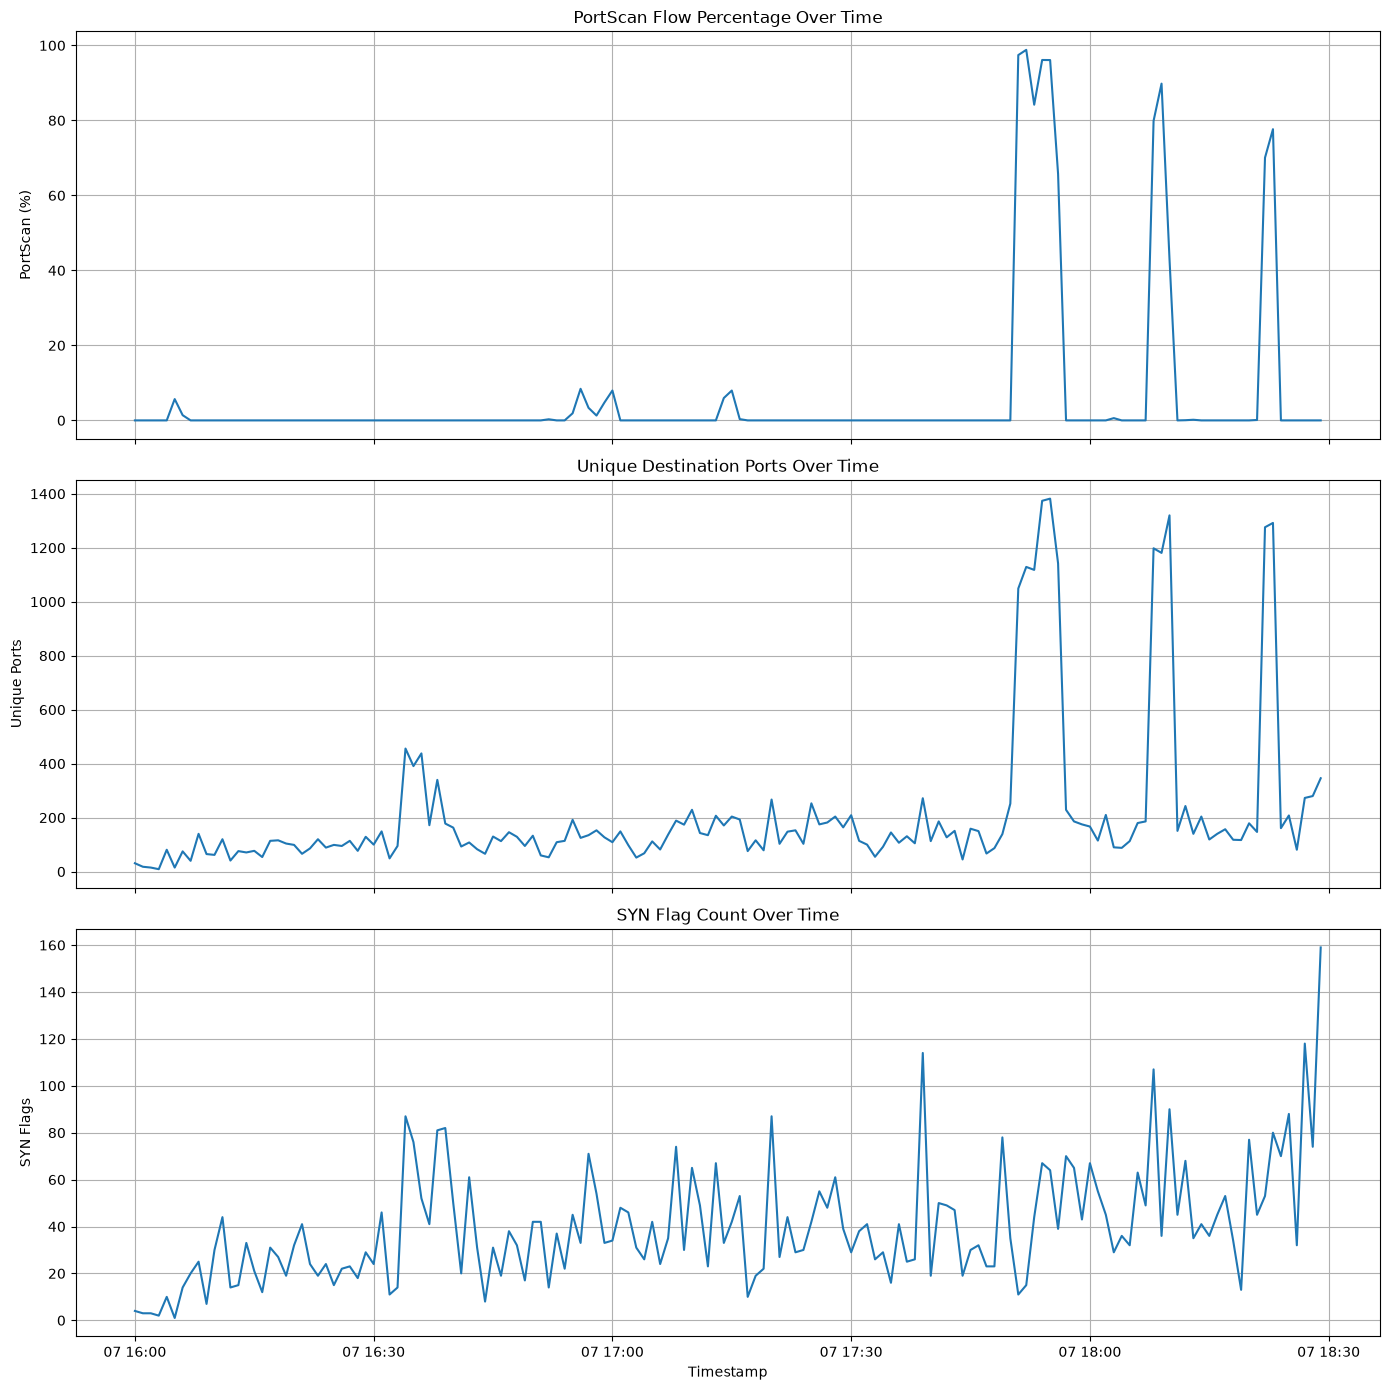


Task 5 temporal analysis complete. Original dataframes were not modified.


In [3]:
# Run this cell after loading both datasets and defining the temporal-analysis function.
if "monday_df" not in globals() or "portscan_df" not in globals():
    raise NameError(
        "monday_df and portscan_df are not loaded. Run the data-loading cell first."
    )

portscan_timeline, monday_timeline = build_temporal_analysis(
    portscan_df,
    monday_df,
)

print("\nTask 5 temporal analysis complete. Original dataframes were not modified.")


In [6]:
def analyze_timestamp_intervals(df, name):
    """Analyze consecutive unique timestamps without modifying the source dataframe."""
    timestamp_series = pd.Series(df["Timestamp"].dropna().unique())
    sorted_timestamps = timestamp_series.sort_values().reset_index(drop=True)
    intervals = sorted_timestamps.diff().dropna()
    interval_seconds = intervals.dt.total_seconds()

    print(f"\n===== {name} TIMESTAMP INTERVAL ANALYSIS =====")
    print("Number of unique timestamps:", len(sorted_timestamps))

    if sorted_timestamps.empty:
        print("No timestamps available for analysis.")
        return {
            "sorted_timestamps": sorted_timestamps,
            "intervals": intervals,
            "interval_seconds": interval_seconds,
        }

    print("First timestamp:", sorted_timestamps.iloc[0])
    print("Last timestamp:", sorted_timestamps.iloc[-1])

    if interval_seconds.empty:
        print("Only one unique timestamp is available; interval statistics are unavailable.")
        return {
            "sorted_timestamps": sorted_timestamps,
            "intervals": intervals,
            "interval_seconds": interval_seconds,
        }

    print("\nInterval statistics in seconds:")
    print("Minimum interval:", interval_seconds.min())
    print("Maximum interval:", interval_seconds.max())
    print("Median interval:", interval_seconds.median())
    print("Mean interval:", interval_seconds.mean())

    print("\nFrequency of each interval in seconds:")
    print(interval_seconds.value_counts().sort_index())

    largest_gaps = (
        pd.DataFrame(
            {
                "previous_timestamp": sorted_timestamps.iloc[:-1].to_numpy(),
                "next_timestamp": sorted_timestamps.iloc[1:].to_numpy(),
                "gap_seconds": interval_seconds.to_numpy(),
            }
        )
        .sort_values("gap_seconds", ascending=False)
        .head(10)
    )
    print("\nLargest 10 gaps:")
    print(largest_gaps)

    one_minute_count = int((interval_seconds == 60).sum())
    total_intervals = len(interval_seconds)
    one_minute_fraction = one_minute_count / total_intervals
    approximately_one_minute = bool(interval_seconds.median() == 60)
    print("\nApproximately one-minute interval check:")
    print("Intervals exactly 60 seconds:", one_minute_count)
    print("Total consecutive intervals:", total_intervals)
    print("Fraction exactly 60 seconds:", one_minute_fraction)
    print("Median interval is 60 seconds:", approximately_one_minute)

    expected_one_minute = pd.date_range(
        start=sorted_timestamps.iloc[0],
        end=sorted_timestamps.iloc[-1],
        freq="60s",
    )
    observed_timestamp_set = set(sorted_timestamps)
    missing_one_minute = [
        timestamp
        for timestamp in expected_one_minute
        if timestamp not in observed_timestamp_set
    ]
    print("\nExpected one-minute timestamps:", len(expected_one_minute))
    print("Missing expected one-minute timestamps:", len(missing_one_minute))

    return {
        "sorted_timestamps": sorted_timestamps,
        "intervals": intervals,
        "interval_seconds": interval_seconds,
        "largest_gaps": largest_gaps,
        "missing_one_minute": missing_one_minute,
    }


In [7]:
# Run this cell after loading both datasets and defining the interval-analysis function.
if "monday_df" not in globals() or "portscan_df" not in globals():
    raise NameError(
        "monday_df and portscan_df are not loaded. Run the data-loading cell first."
    )

portscan_interval_analysis = analyze_timestamp_intervals(
    portscan_df,
    "portscan_df",
)

monday_interval_analysis = analyze_timestamp_intervals(
    monday_df,
    "monday_df",
)

print("\nTask 6 timestamp interval analysis complete. Original dataframes were not modified.")



===== portscan_df TIMESTAMP INTERVAL ANALYSIS =====
Number of unique timestamps: 150
First timestamp: 2017-07-07 16:00:00
Last timestamp: 2017-07-07 18:29:00

Interval statistics in seconds:
Minimum interval: 60.0
Maximum interval: 60.0
Median interval: 60.0
Mean interval: 60.0

Frequency of each interval in seconds:
60.0    149
Name: count, dtype: int64

Largest 10 gaps:
   previous_timestamp      next_timestamp  gap_seconds
0 2017-07-07 16:00:00 2017-07-07 16:01:00         60.0
1 2017-07-07 16:01:00 2017-07-07 16:02:00         60.0
2 2017-07-07 16:02:00 2017-07-07 16:03:00         60.0
3 2017-07-07 16:03:00 2017-07-07 16:04:00         60.0
4 2017-07-07 16:04:00 2017-07-07 16:05:00         60.0
5 2017-07-07 16:05:00 2017-07-07 16:06:00         60.0
6 2017-07-07 16:06:00 2017-07-07 16:07:00         60.0
7 2017-07-07 16:07:00 2017-07-07 16:08:00         60.0
8 2017-07-07 16:08:00 2017-07-07 16:09:00         60.0
9 2017-07-07 16:09:00 2017-07-07 16:10:00         60.0

Approximately one-

In [2]:
clean_rate_columns = [
    "Flow Bytes/s",
    "Flow Packets/s",
]

clean_negative_columns = [
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
]

clean_sentinel_columns = [
    "Init_Win_bytes_forward",
    "Init_Win_bytes_backward",
]

constant_columns_to_remove = [
    "Bwd PSH Flags",
    "Fwd URG Flags",
    "Bwd URG Flags",
    "CWE Flag Count",
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",
]


def clean_cicids_copy(df):
    """Create a cleaned copy without modifying the input dataframe."""
    cleaned = df.copy(deep=True)
    numeric_columns = cleaned.select_dtypes(include=[np.number]).columns

    # Convert all numeric positive and negative infinity values to NaN.
    cleaned.loc[:, numeric_columns] = cleaned.loc[:, numeric_columns].replace(
        [np.inf, -np.inf], np.nan
    )

    # Convert invalid negative rates and negative timing values to NaN.
    for column in clean_rate_columns + clean_negative_columns:
        if column in cleaned.columns:
            cleaned.loc[cleaned[column] < 0, column] = np.nan

    # Convert only the documented -1 window sentinel; retain zero values.
    for column in clean_sentinel_columns:
        if column in cleaned.columns:
            cleaned.loc[cleaned[column] == -1, column] = np.nan

    columns_present_to_remove = [
        column for column in constant_columns_to_remove if column in cleaned.columns
    ]
    cleaned = cleaned.drop(columns=columns_present_to_remove)

    return cleaned, columns_present_to_remove


def dataframe_signature(df):
    """Create a read-only signature for checking whether a dataframe changed."""
    return (
        df.shape,
        tuple(df.columns),
        tuple(str(dtype) for dtype in df.dtypes),
        int(pd.util.hash_pandas_object(df, index=True).sum()),
    )


def report_cleaning_results(original, cleaned, removed_columns, name):
    print(f"\n===== {name} CLEANING REPORT =====")
    print("Shape before:", original.shape)
    print("Shape after:", cleaned.shape)
    print("Columns removed:", removed_columns)
    print("Total NaN values:", int(cleaned.isna().sum().sum()))

    affected_columns = [
        column for column in clean_rate_columns + clean_negative_columns + clean_sentinel_columns
        if column in cleaned.columns
    ]
    nan_counts = cleaned[affected_columns].isna().sum()
    print("\nNaN count per affected column:")
    print(nan_counts[nan_counts > 0])

    numeric_cleaned = cleaned.select_dtypes(include=[np.number])
    remaining_infinity_count = int(
        np.isinf(numeric_cleaned.to_numpy(dtype=float, na_value=np.nan)).sum()
    )
    print("\nRemaining infinity count:", remaining_infinity_count)

    print("Remaining negative values in specifically cleaned columns:")
    for column in affected_columns:
        print(f"{column}: {int((cleaned[column] < 0).sum())}")

    print("\nLabel distribution:")
    print(cleaned["Label"].value_counts(dropna=False))

    print("\nTimestamp min/max:")
    print(cleaned["Timestamp"].min(), "to", cleaned["Timestamp"].max())


In [3]:
# Run this cell after loading monday_df and portscan_df and defining the cleaning functions.
if "monday_df" not in globals() or "portscan_df" not in globals():
    raise NameError(
        "monday_df and portscan_df are not loaded. Run the data-loading cell first."
    )

monday_original_signature = dataframe_signature(monday_df)
portscan_original_signature = dataframe_signature(portscan_df)

monday_clean, monday_removed_columns = clean_cicids_copy(monday_df)
portscan_clean, portscan_removed_columns = clean_cicids_copy(portscan_df)

report_cleaning_results(
    monday_df,
    monday_clean,
    monday_removed_columns,
    "monday_df -> monday_clean",
)

report_cleaning_results(
    portscan_df,
    portscan_clean,
    portscan_removed_columns,
    "portscan_df -> portscan_clean",
)

print("\n===== ORIGINAL DATAFRAME VERIFICATION =====")
print("monday_df unchanged:", dataframe_signature(monday_df) == monday_original_signature)
print("portscan_df unchanged:", dataframe_signature(portscan_df) == portscan_original_signature)
print("\nTask 7 cleaning complete. Original dataframes were not modified.")



===== monday_df -> monday_clean CLEANING REPORT =====
Shape before: (529918, 85)
Shape after: (529918, 75)
Columns removed: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Total NaN values: 525044

NaN count per affected column:
Flow Bytes/s                  446
Flow Packets/s                452
Flow Duration                  15
Flow IAT Mean                  15
Flow IAT Max                   15
Flow IAT Min                  512
Init_Win_bytes_forward     224495
Init_Win_bytes_backward    299094
dtype: int64

Remaining infinity count: 0
Remaining negative values in specifically cleaned columns:
Flow Bytes/s: 0
Flow Packets/s: 0
Flow Duration: 0
Flow IAT Mean: 0
Flow IAT Max: 0
Flow IAT Min: 0
Init_Win_bytes_forward: 0
Init_Win_bytes_backward: 0

Label distribution:
Label
BENIGN    529918
Name: count, dtype: int64

Timestamp min/max

In [10]:
candidate_feature_columns = {
    "total_flow_count": ("Flow ID", "count"),
    "total_forward_packets": ("Total Fwd Packets", "sum"),
    "total_backward_packets": ("Total Backward Packets", "sum"),
    "total_forward_bytes": ("Total Length of Fwd Packets", "sum"),
    "total_backward_bytes": ("Total Length of Bwd Packets", "sum"),
    "unique_source_ips": ("Source IP", "nunique"),
    "unique_destination_ips": ("Destination IP", "nunique"),
    "unique_source_ports": ("Source Port", "nunique"),
    "unique_destination_ports": ("Destination Port", "nunique"),
    "total_syn_flags": ("SYN Flag Count", "sum"),
    "total_ack_flags": ("ACK Flag Count", "sum"),
    "total_rst_flags": ("RST Flag Count", "sum"),
    "total_fin_flags": ("FIN Flag Count", "sum"),
    "total_psh_flags": ("PSH Flag Count", "sum"),
    "mean_flow_duration": ("Flow Duration", "mean"),
    "median_flow_duration": ("Flow Duration", "median"),
    "mean_packet_size": ("Average Packet Size", "mean"),
    "mean_flow_bytes_per_second": ("Flow Bytes/s", "mean"),
    "mean_flow_packets_per_second": ("Flow Packets/s", "mean"),
    "mean_flow_iat": ("Flow IAT Mean", "mean"),
}


def build_minute_feature_table(df, include_attack_indicator=False):
    required_columns = {"Timestamp"}
    required_columns.update(column for column, _ in candidate_feature_columns.values())
    if include_attack_indicator:
        required_columns.add("Label")

    missing_columns = sorted(required_columns - set(df.columns))
    if missing_columns:
        raise KeyError(f"Missing required columns: {missing_columns}")

    temporary = df[list(required_columns)].copy()
    temporary["Minute"] = temporary["Timestamp"].dt.floor("min")

    aggregations = {
        feature_name: (source_column, aggregation)
        for feature_name, (source_column, aggregation) in candidate_feature_columns.items()
    }
    minute_features = temporary.groupby("Minute", sort=True).agg(**aggregations)
    minute_features["total_packets"] = (
        minute_features["total_forward_packets"]
        + minute_features["total_backward_packets"]
    )
    minute_features["total_bytes"] = (
        minute_features["total_forward_bytes"]
        + minute_features["total_backward_bytes"]
    )

    if include_attack_indicator:
        attack_by_minute = temporary.groupby("Minute")["Label"].agg(
            lambda labels: int((labels == "PortScan").any())
        )
        minute_features["attack_indicator"] = attack_by_minute

    return minute_features


def analyze_candidate_features(monday_clean, portscan_clean):
    monday_minute_features = build_minute_feature_table(monday_clean)
    portscan_minute_features = build_minute_feature_table(
        portscan_clean,
        include_attack_indicator=True,
    )

    feature_order = list(candidate_feature_columns) + ["total_packets", "total_bytes"]
    summary_tables = []
    for dataset_name, minute_features in [
        ("monday_clean", monday_minute_features),
        ("portscan_clean", portscan_minute_features),
    ]:
        statistics = minute_features[feature_order].agg(["min", "max", "mean", "std"]).T
        statistics["meaningful_variation"] = (
            minute_features[feature_order].nunique(dropna=True) > 1
        )
        statistics.insert(0, "dataset", dataset_name)
        statistics.insert(1, "feature", statistics.index)
        summary_tables.append(statistics.reset_index(drop=True))

    feature_statistics = pd.concat(summary_tables, ignore_index=True)
    print("===== MINUTE-LEVEL CANDIDATE FEATURE STATISTICS =====")
    print(feature_statistics)

    attack_correlations = portscan_minute_features[feature_order + ["attack_indicator"]].corr(
        numeric_only=True
    )["attack_indicator"].drop("attack_indicator").sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )
    attack_ranking = pd.DataFrame(
        {
            "feature": attack_correlations.index,
            "correlation_with_portscan": attack_correlations.values,
        }
    )
    attack_ranking["absolute_correlation"] = attack_ranking[
        "correlation_with_portscan"
    ].abs()
    print("\n===== FEATURES RANKED BY ABSOLUTE PORTSCAN CORRELATION =====")
    print(attack_ranking)

    candidate_correlation = portscan_minute_features[feature_order].corr()
    print("\n===== CANDIDATE FEATURE CORRELATION MATRIX =====")
    print(candidate_correlation)

    redundant_pairs = []
    for row_index, feature_a in enumerate(feature_order):
        for feature_b in feature_order[row_index + 1:]:
            correlation = candidate_correlation.loc[feature_a, feature_b]
            if pd.notna(correlation) and abs(correlation) >= 0.95:
                redundant_pairs.append(
                    {
                        "feature_a": feature_a,
                        "feature_b": feature_b,
                        "correlation": correlation,
                        "absolute_correlation": abs(correlation),
                    }
                )
    redundant_pairs = pd.DataFrame(redundant_pairs).sort_values(
        "absolute_correlation",
        ascending=False,
    ) if redundant_pairs else pd.DataFrame(
        columns=["feature_a", "feature_b", "correlation", "absolute_correlation"]
    )
    print("\n===== HIGHLY REDUNDANT FEATURE PAIRS (|correlation| >= 0.95) =====")
    print(redundant_pairs)

    figure, axis = plt.subplots(figsize=(14, 12))
    image = axis.imshow(candidate_correlation, cmap="coolwarm", vmin=-1, vmax=1)
    axis.set_xticks(range(len(feature_order)), feature_order, rotation=90)
    axis.set_yticks(range(len(feature_order)), feature_order)
    axis.set_title("Minute-Level Candidate Feature Correlation")
    figure.colorbar(image, ax=axis, label="Correlation")
    figure.tight_layout()
    plt.show()

    return {
        "monday_minute_features": monday_minute_features,
        "portscan_minute_features": portscan_minute_features,
        "feature_statistics": feature_statistics,
        "attack_ranking": attack_ranking,
        "candidate_correlation": candidate_correlation,
        "redundant_pairs": redundant_pairs,
    }


===== MINUTE-LEVEL CANDIDATE FEATURE STATISTICS =====
           dataset                       feature            min           max  \
0     monday_clean              total_flow_count       4.000000  3.768000e+03   
1     monday_clean         total_forward_packets       8.000000  2.368140e+05   
2     monday_clean        total_backward_packets       0.000000  3.132150e+05   
3     monday_clean           total_forward_bytes      48.000000  3.190718e+06   
4     monday_clean          total_backward_bytes       0.000000  6.787510e+08   
5     monday_clean             unique_source_ips       1.000000  2.320000e+02   
6     monday_clean        unique_destination_ips       1.000000  4.380000e+02   
7     monday_clean           unique_source_ports       1.000000  2.994000e+03   
8     monday_clean      unique_destination_ports       1.000000  9.300000e+02   
9     monday_clean               total_syn_flags       0.000000  2.980000e+02   
10    monday_clean               total_ack_flags       

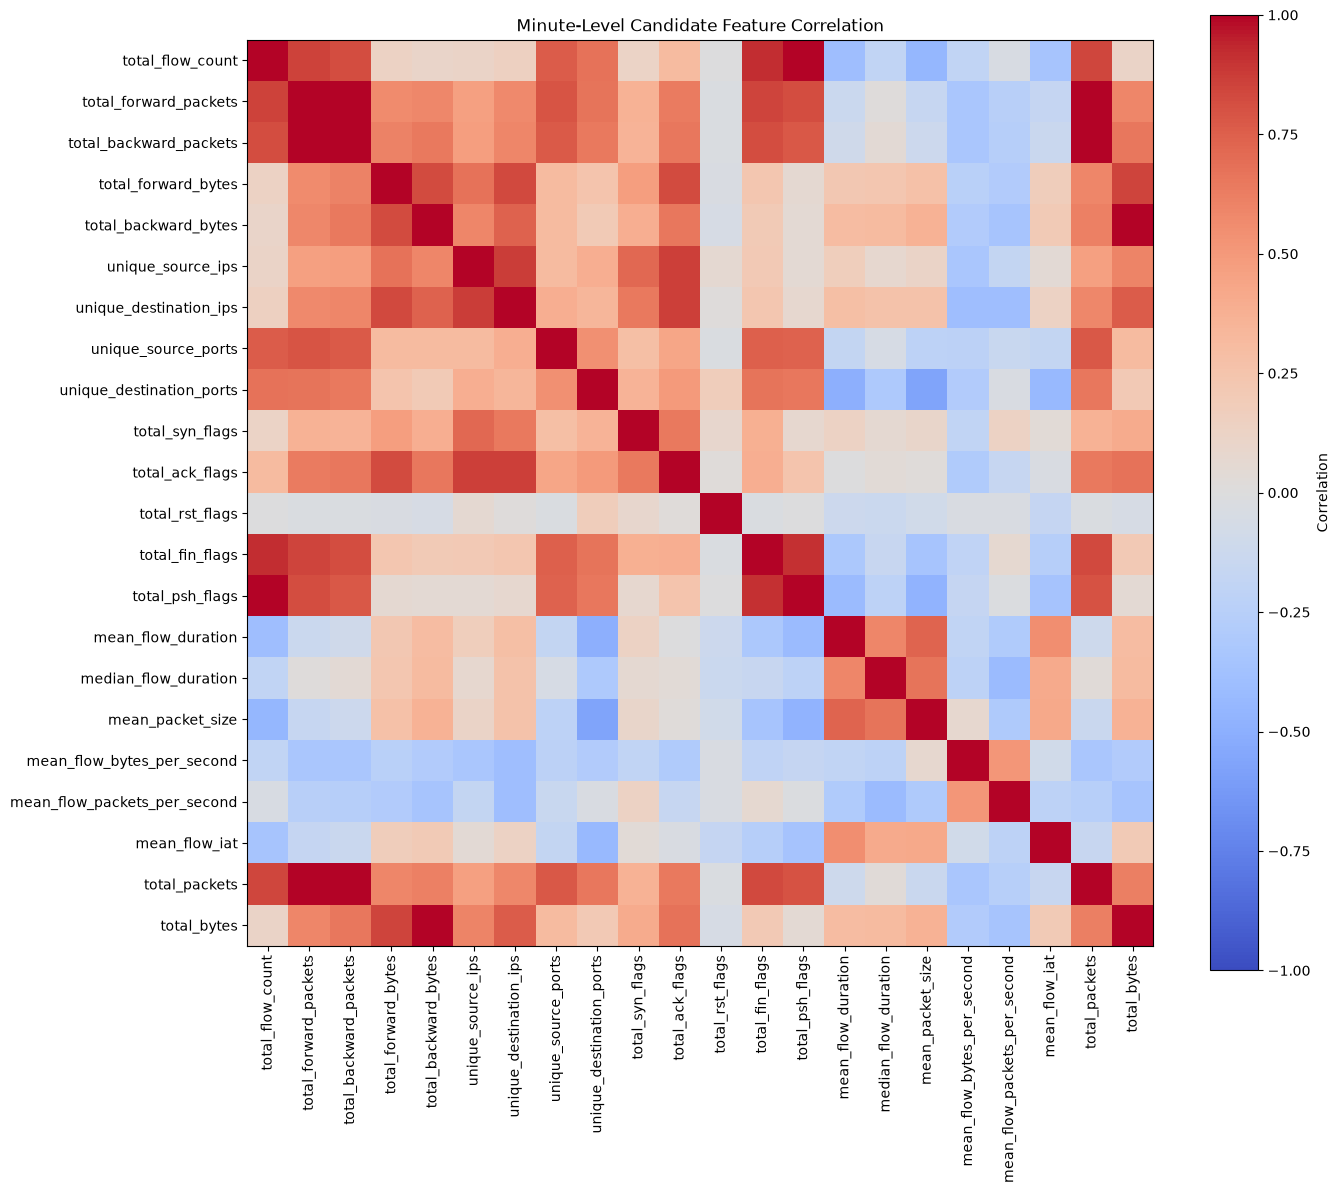


===== CLEANED DATAFRAME VERIFICATION =====
monday_clean unchanged: True
portscan_clean unchanged: True

Task 8 feature analysis complete. No cleaned dataframe was modified.


In [11]:
# Run this cell after creating monday_clean and portscan_clean and defining the feature-analysis functions.
if "monday_clean" not in globals() or "portscan_clean" not in globals():
    raise NameError(
        "monday_clean and portscan_clean are not available. Run Task 7 first."
    )

monday_clean_signature_before_task_8 = dataframe_signature(monday_clean)
portscan_clean_signature_before_task_8 = dataframe_signature(portscan_clean)

task_8_results = analyze_candidate_features(
    monday_clean,
    portscan_clean,
)

print("\n===== CLEANED DATAFRAME VERIFICATION =====")
print(
    "monday_clean unchanged:",
    dataframe_signature(monday_clean) == monday_clean_signature_before_task_8,
)
print(
    "portscan_clean unchanged:",
    dataframe_signature(portscan_clean) == portscan_clean_signature_before_task_8,
)
print("\nTask 8 feature analysis complete. No cleaned dataframe was modified.")


In [4]:
state_numeric_aggregations = {
    "total_flow_count": ("Flow ID", "count"),
    "total_forward_packets": ("Total Fwd Packets", "sum"),
    "total_backward_packets": ("Total Backward Packets", "sum"),
    "total_forward_bytes": ("Total Length of Fwd Packets", "sum"),
    "total_backward_bytes": ("Total Length of Bwd Packets", "sum"),
    "unique_source_ips": ("Source IP", "nunique"),
    "unique_destination_ips": ("Destination IP", "nunique"),
    "unique_source_ports": ("Source Port", "nunique"),
    "unique_destination_ports": ("Destination Port", "nunique"),
    "total_syn_flags": ("SYN Flag Count", "sum"),
    "total_ack_flags": ("ACK Flag Count", "sum"),
    "total_rst_flags": ("RST Flag Count", "sum"),
    "mean_flow_duration": ("Flow Duration", "mean"),
    "mean_packet_size": ("Average Packet Size", "mean"),
    "mean_flow_iat": ("Flow IAT Mean", "mean"),
}


def safe_divide(numerator, denominator):
    return numerator.div(denominator.where(denominator != 0))


def build_network_states(df, include_attack_details=False):
    """Create chronological minute states from a source dataframe copy."""
    required_columns = {"Timestamp", "Flow ID", "Label"}
    required_columns.update(
        source_column for source_column, _ in state_numeric_aggregations.values()
    )
    missing_columns = sorted(required_columns - set(df.columns))
    if missing_columns:
        raise KeyError(f"Missing required columns: {missing_columns}")

    temporary = df[list(required_columns)].copy()
    temporary["Timestamp"] = temporary["Timestamp"].dt.floor("min")

    states = temporary.groupby("Timestamp", sort=True).agg(
        **state_numeric_aggregations
    )
    states["total_packets"] = (
        states["total_forward_packets"] + states["total_backward_packets"]
    )
    states["total_bytes"] = (
        states["total_forward_bytes"] + states["total_backward_bytes"]
    )

    states["syn_per_flow"] = safe_divide(
        states["total_syn_flags"], states["total_flow_count"]
    )
    states["packets_per_flow"] = safe_divide(
        states["total_packets"], states["total_flow_count"]
    )
    states["bytes_per_flow"] = safe_divide(
        states["total_bytes"], states["total_flow_count"]
    )
    states["ports_per_source_ip"] = safe_divide(
        states["unique_destination_ports"], states["unique_source_ips"]
    )

    if include_attack_details:
        states["portscan_flow_count"] = temporary.groupby("Timestamp")["Label"].agg(
            lambda labels: (labels == "PortScan").sum()
        )
        states["benign_flow_count"] = temporary.groupby("Timestamp")["Label"].agg(
            lambda labels: (labels == "BENIGN").sum()
        )
        states["portscan_percentage"] = safe_divide(
            states["portscan_flow_count"] * 100,
            states["total_flow_count"],
        )
        states["attack_state"] = (
            states["portscan_flow_count"] > 0
        ).astype("int8")
        states["Label"] = np.where(states["attack_state"] == 1, "PortScan", "BENIGN")
    else:
        states["portscan_flow_count"] = 0
        states["benign_flow_count"] = states["total_flow_count"]
        states["portscan_percentage"] = 0.0
        states["attack_state"] = 0
        states["Label"] = "BENIGN"

    return states.sort_index()


def report_network_states(states, name):
    print(f"\n===== {name} =====")
    print("Shape:", states.shape)
    print("Complete column list:")
    print(list(states.columns))
    print("\nFirst 10 rows:")
    print(states.head(10))
    print("\nLast 10 rows:")
    print(states.tail(10))

    state_feature_columns = [
        column for column in states.columns
        if column not in {
            "Label",
            "attack_state",
            "portscan_flow_count",
            "benign_flow_count",
            "portscan_percentage",
        }
    ]
    print("\nNaN count per state feature:")
    print(states[state_feature_columns].isna().sum())

    numeric_states = states.select_dtypes(include=[np.number])
    infinity_count = int(
        np.isinf(numeric_states.to_numpy(dtype=float, na_value=np.nan)).sum()
    )
    print("\nInfinity count:", infinity_count)

    print("\nLabel distribution:")
    print(states["Label"].value_counts())
    print("\nAttack-state distribution:")
    print(states["attack_state"].value_counts().sort_index())

    print("\nTimestamp min/max:")
    print(states.index.min(), "to", states.index.max())


In [5]:
# Run this cell after creating monday_clean and portscan_clean and defining the state-builder functions.
if "monday_clean" not in globals() or "portscan_clean" not in globals():
    raise NameError(
        "monday_clean and portscan_clean are not available. Run Task 7 first."
    )

monday_clean_signature_before_task_9 = dataframe_signature(monday_clean)
portscan_clean_signature_before_task_9 = dataframe_signature(portscan_clean)

monday_states = build_network_states(monday_clean, include_attack_details=False)
portscan_states = build_network_states(portscan_clean, include_attack_details=True)

report_network_states(monday_states, "monday_states")
report_network_states(portscan_states, "portscan_states")

print("\n===== SOURCE DATAFRAME VERIFICATION =====")
print(
    "monday_clean unchanged:",
    dataframe_signature(monday_clean) == monday_clean_signature_before_task_9,
)
print(
    "portscan_clean unchanged:",
    dataframe_signature(portscan_clean) == portscan_clean_signature_before_task_9,
)
print("\nTask 9 network state construction complete. Source dataframes were not modified.")



===== monday_states =====
Shape: (487, 26)
Complete column list:
['total_flow_count', 'total_forward_packets', 'total_backward_packets', 'total_forward_bytes', 'total_backward_bytes', 'unique_source_ips', 'unique_destination_ips', 'unique_source_ports', 'unique_destination_ports', 'total_syn_flags', 'total_ack_flags', 'total_rst_flags', 'mean_flow_duration', 'mean_packet_size', 'mean_flow_iat', 'total_packets', 'total_bytes', 'syn_per_flow', 'packets_per_flow', 'bytes_per_flow', 'ports_per_source_ip', 'portscan_flow_count', 'benign_flow_count', 'portscan_percentage', 'attack_state', 'Label']

First 10 rows:
                     total_flow_count  total_forward_packets  \
Timestamp                                                      
2017-07-03 11:55:00                 4                      8   
2017-07-03 11:56:00                86                   1236   
2017-07-03 11:57:00               415                   3666   
2017-07-03 11:58:00               185                   1477   


In [6]:
MODEL_FEATURES = [
    "total_flow_count",
    "total_packets",
    "total_bytes",
    "unique_source_ips",
    "unique_destination_ips",
    "unique_source_ports",
    "unique_destination_ports",
    "total_syn_flags",
    "total_ack_flags",
    "total_rst_flags",
    "mean_flow_duration",
    "mean_packet_size",
    "mean_flow_iat",
    "syn_per_flow",
    "packets_per_flow",
    "bytes_per_flow",
    "ports_per_source_ip",
]

LABEL_DERIVED_COLUMNS = {
    "portscan_flow_count",
    "benign_flow_count",
    "portscan_percentage",
    "attack_state",
    "Label",
}


def validate_state_timestamps(states, name):
    timestamps = states.index
    sorted_chronologically = timestamps.is_monotonic_increasing
    timestamps_unique = timestamps.is_unique
    intervals = timestamps.to_series().diff().dropna()
    exact_one_minute = bool((intervals == pd.Timedelta(minutes=1)).all())
    non_one_minute_intervals = intervals[intervals != pd.Timedelta(minutes=1)]

    print(f"\n===== {name} TIMESTAMP VALIDATION =====")
    print("Sorted chronologically:", sorted_chronologically)
    print("Timestamps unique:", timestamps_unique)
    print("Exactly one-minute intervals:", exact_one_minute)
    print("Number of non-one-minute intervals:", len(non_one_minute_intervals))
    if len(non_one_minute_intervals):
        print(non_one_minute_intervals.head(10))

    return {
        "sorted_chronologically": sorted_chronologically,
        "timestamps_unique": timestamps_unique,
        "exact_one_minute": exact_one_minute,
        "non_one_minute_intervals": non_one_minute_intervals,
    }


def consecutive_run_lengths(values):
    groups = values.ne(values.shift()).cumsum()
    return values.groupby(groups).agg(["first", "size"])


def validate_attack_timeline(states):
    attack_states = states["attack_state"]
    transitions = attack_states.ne(attack_states.shift())
    transition_rows = states.loc[transitions].copy()
    transition_rows["transition_from"] = attack_states.shift().loc[transitions].values
    transition_rows["transition_to"] = attack_states.loc[transitions].values

    transition_pairs = list(
        zip(attack_states.shift().dropna().astype(int), attack_states.iloc[1:].astype(int))
    )
    benign_to_portscan = transition_pairs.count((0, 1))
    portscan_to_benign = transition_pairs.count((1, 0))

    runs = consecutive_run_lengths(attack_states.astype(int))
    benign_runs = runs.loc[runs["first"] == 0, "size"]
    portscan_runs = runs.loc[runs["first"] == 1, "size"]

    attack_minutes = int((attack_states == 1).sum())
    attack_timestamps = states.index[attack_states == 1]

    print("\n===== PORTSCAN ATTACK TIMELINE VALIDATION =====")
    print("Total attack minutes:", attack_minutes)
    print("First PortScan minute:", attack_timestamps.min() if len(attack_timestamps) else "None")
    print("Last PortScan minute:", attack_timestamps.max() if len(attack_timestamps) else "None")
    print("BENIGN -> PortScan transitions:", benign_to_portscan)
    print("PortScan -> BENIGN transitions:", portscan_to_benign)
    print("Longest consecutive BENIGN run:", int(benign_runs.max()) if len(benign_runs) else 0)
    print("Longest consecutive PortScan run:", int(portscan_runs.max()) if len(portscan_runs) else 0)

    print("\nEvery minute where attack_state changes:")
    print(transition_rows[["transition_from", "transition_to", "attack_state", "Label"]])

    transition_columns = [
        "unique_destination_ports",
        "total_flow_count",
        "total_syn_flags",
        "total_packets",
        "total_bytes",
        "portscan_flow_count",
        "portscan_percentage",
        "attack_state",
        "Label",
    ]
    transition_indices = set()
    for position in np.flatnonzero(transitions.to_numpy()):
        transition_indices.update(
            range(max(0, position - 1), min(len(states), position + 2))
        )
    transition_context = states.iloc[sorted(transition_indices)][transition_columns]
    print("\nState columns around every attack transition:")
    print(transition_context)

    return transition_rows, transition_context


def plot_attack_timeline(states):
    figure, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
    attack_mask = states["attack_state"] == 1

    axes[0].plot(states.index, states["attack_state"], drawstyle="steps-post")
    axes[0].fill_between(
        states.index,
        0,
        states["attack_state"],
        step="post",
        alpha=0.25,
        label="PortScan period",
    )
    axes[0].set_ylabel("attack_state")
    axes[0].set_title("Minute-Level Attack State")
    axes[0].set_yticks([0, 1])
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(
        states.index,
        states["unique_destination_ports"],
        label="Unique destination ports",
    )
    axes[1].scatter(
        states.index[attack_mask],
        states.loc[attack_mask, "unique_destination_ports"],
        color="red",
        label="PortScan minute",
        zorder=3,
    )
    axes[1].set_xlabel("Timestamp")
    axes[1].set_ylabel("Unique destination ports")
    axes[1].set_title("Destination Port Diversity with PortScan Minutes")
    axes[1].legend()
    axes[1].grid(True)

    figure.tight_layout()
    plt.show()


In [7]:
# Run this cell after creating monday_states and portscan_states and defining validation functions.
if "monday_states" not in globals() or "portscan_states" not in globals():
    raise NameError(
        "monday_states and portscan_states are not available. Run Task 9 first."
    )

monday_states_signature_before_task_10 = dataframe_signature(monday_states)
portscan_states_signature_before_task_10 = dataframe_signature(portscan_states)

monday_timestamp_validation = validate_state_timestamps(monday_states, "monday_states")
portscan_timestamp_validation = validate_state_timestamps(
    portscan_states,
    "portscan_states",
)
transition_rows, transition_context = validate_attack_timeline(portscan_states)
plot_attack_timeline(portscan_states)

model_feature_set = set(MODEL_FEATURES)
missing_model_features = model_feature_set - set(portscan_states.columns)
label_derived_model_features = model_feature_set & LABEL_DERIVED_COLUMNS
non_numeric_model_features = [
    feature for feature in MODEL_FEATURES
    if feature in portscan_states.columns
    and not pd.api.types.is_numeric_dtype(portscan_states[feature])
]

print("\n===== MODEL FEATURE VALIDATION =====")
print("MODEL_FEATURES:", MODEL_FEATURES)
print("Missing model features:", sorted(missing_model_features))
print("Label-derived model features:", sorted(label_derived_model_features))
print("Non-numeric model features:", non_numeric_model_features)
print("Excluded label-derived columns:", sorted(LABEL_DERIVED_COLUMNS - model_feature_set))

sources_unchanged = (
    dataframe_signature(monday_states) == monday_states_signature_before_task_10
    and dataframe_signature(portscan_states) == portscan_states_signature_before_task_10
)
validation_passed = all([
    monday_timestamp_validation["sorted_chronologically"],
    monday_timestamp_validation["timestamps_unique"],
    monday_timestamp_validation["exact_one_minute"],
    portscan_timestamp_validation["sorted_chronologically"],
    portscan_timestamp_validation["timestamps_unique"],
    portscan_timestamp_validation["exact_one_minute"],
    not missing_model_features,
    not label_derived_model_features,
    not non_numeric_model_features,
    sources_unchanged,
])

print("\n===== FINAL TEMPORAL STATE READINESS REPORT =====")
print("monday_states unchanged:", dataframe_signature(monday_states) == monday_states_signature_before_task_10)
print("portscan_states unchanged:", dataframe_signature(portscan_states) == portscan_states_signature_before_task_10)
print("Ready for preprocessing/model training:", validation_passed)
if not validation_passed:
    print("Review the failed checks above before proceeding.")
else:
    print("All temporal, feature-integrity, and model-input checks passed.")



===== monday_states TIMESTAMP VALIDATION =====
Sorted chronologically: True
Timestamps unique: True
Exactly one-minute intervals: True
Number of non-one-minute intervals: 0

===== portscan_states TIMESTAMP VALIDATION =====
Sorted chronologically: True
Timestamps unique: True
Exactly one-minute intervals: True
Number of non-one-minute intervals: 0

===== PORTSCAN ATTACK TIMELINE VALIDATION =====
Total attack minutes: 27
First PortScan minute: 2017-07-07 16:05:00
Last PortScan minute: 2017-07-07 18:23:00
BENIGN -> PortScan transitions: 9
PortScan -> BENIGN transitions: 9
Longest consecutive BENIGN run: 45
Longest consecutive PortScan run: 6

Every minute where attack_state changes:
                     transition_from  transition_to  attack_state     Label
Timestamp                                                                  
2017-07-07 16:00:00              NaN              0             0    BENIGN
2017-07-07 16:05:00              0.0              1             1  PortScan
2017-0

NameError: name 'plt' is not defined

In [8]:
SPLIT_METADATA_COLUMNS = [
    "Timestamp",
    "attack_state",
    "Label",
    "portscan_flow_count",
    "benign_flow_count",
    "portscan_percentage",
]


def states_with_timestamp_column(states, source_day):
    selected_columns = MODEL_FEATURES + [
        column for column in SPLIT_METADATA_COLUMNS if column != "Timestamp"
    ]
    result = states[selected_columns].copy().reset_index()
    result["source_day"] = source_day
    return result


def build_chronological_splits(monday_states, portscan_states):
    monday_for_training = states_with_timestamp_column(monday_states, "Monday")
    friday_states = states_with_timestamp_column(portscan_states, "Friday")

    friday_count = len(friday_states)
    train_end = int(friday_count * 0.60)
    validation_end = train_end + int(friday_count * 0.20)

    friday_training = friday_states.iloc[:train_end].copy()
    friday_validation = friday_states.iloc[train_end:validation_end].copy()
    friday_test = friday_states.iloc[validation_end:].copy()

    train_states = pd.concat(
        [monday_for_training, friday_training],
        ignore_index=True,
    ).sort_values(["Timestamp", "source_day"]).reset_index(drop=True)
    validation_states = friday_validation.sort_values("Timestamp").reset_index(drop=True)
    test_states = friday_test.sort_values("Timestamp").reset_index(drop=True)

    return train_states, validation_states, test_states


def report_split(split, name):
    attack_count = int((split["attack_state"] == 1).sum())
    benign_count = int((split["attack_state"] == 0).sum())
    attack_percentage = attack_count / len(split) * 100 if len(split) else 0.0
    chronological = split["Timestamp"].is_monotonic_increasing
    duplicate_timestamps = int(split["Timestamp"].duplicated().sum())

    print(f"\n===== {name} =====")
    print("Shape:", split.shape)
    print("Minimum timestamp:", split["Timestamp"].min())
    print("Maximum timestamp:", split["Timestamp"].max())
    print("BENIGN states:", benign_count)
    print("PortScan states:", attack_count)
    print("Attack percentage:", attack_percentage)
    print("Source-day distribution:")
    print(split["source_day"].value_counts())
    print("Chronological ordering check:", chronological)
    print("Duplicate timestamp count:", duplicate_timestamps)
    print("\nFirst 5 timestamps:")
    print(split["Timestamp"].head(5).to_list())
    print("Last 5 timestamps:")
    print(split["Timestamp"].tail(5).to_list())

    return {
        "chronological": chronological,
        "duplicate_timestamps": duplicate_timestamps,
        "attack_count": attack_count,
        "benign_count": benign_count,
    }


In [9]:
# Run this cell after creating monday_states and portscan_states and defining split functions.
if "monday_states" not in globals() or "portscan_states" not in globals():
    raise NameError(
        "monday_states and portscan_states are not available. Run Task 9 first."
    )

monday_states_signature_before_task_11 = dataframe_signature(monday_states)
portscan_states_signature_before_task_11 = dataframe_signature(portscan_states)

train_states, validation_states, test_states = build_chronological_splits(
    monday_states,
    portscan_states,
)

train_report = report_split(train_states, "train_states")
validation_report = report_split(validation_states, "validation_states")
test_report = report_split(test_states, "test_states")

training_timestamps = set(train_states["Timestamp"])
validation_timestamps = set(validation_states["Timestamp"])
test_timestamps = set(test_states["Timestamp"])
friday_training_timestamps = set(
    train_states.loc[train_states["source_day"] == "Friday", "Timestamp"]
)
friday_validation_timestamps = set(validation_states["Timestamp"])
friday_test_timestamps = set(test_states["Timestamp"])

split_boundary_checks = {
    "validation_starts_after_training": validation_states["Timestamp"].min() >= train_states["Timestamp"].max(),
    "test_starts_after_validation": test_states["Timestamp"].min() >= validation_states["Timestamp"].max(),
    "no_monday_in_validation": not (validation_states["source_day"] == "Monday").any(),
    "no_monday_in_test": not (test_states["source_day"] == "Monday").any(),
    "no_friday_test_in_training": not friday_test_timestamps.intersection(training_timestamps),
    "no_friday_test_in_validation": not friday_test_timestamps.intersection(validation_timestamps),
    "no_friday_validation_in_test": not friday_validation_timestamps.intersection(test_timestamps),
}

print("\n===== SPLIT BOUNDARY AND LEAKAGE CHECKS =====")
for check_name, passed in split_boundary_checks.items():
    print(f"{check_name}: {passed}")

print("\n===== SOURCE STATE VERIFICATION =====")
print(
    "monday_states unchanged:",
    dataframe_signature(monday_states) == monday_states_signature_before_task_11,
)
print(
    "portscan_states unchanged:",
    dataframe_signature(portscan_states) == portscan_states_signature_before_task_11,
)

expected_sizes = {
    "train_states": len(monday_states) + 90,
    "validation_states": 30,
    "test_states": 30,
}
actual_sizes = {
    "train_states": len(train_states),
    "validation_states": len(validation_states),
    "test_states": len(test_states),
}
print("\nExpected split sizes:", expected_sizes)
print("Actual split sizes:", actual_sizes)

split_ready = all([
    train_report["chronological"],
    validation_report["chronological"],
    test_report["chronological"],
    train_report["duplicate_timestamps"] == 0,
    validation_report["duplicate_timestamps"] == 0,
    test_report["duplicate_timestamps"] == 0,
    actual_sizes == expected_sizes,
    all(split_boundary_checks.values()),
    dataframe_signature(monday_states) == monday_states_signature_before_task_11,
    dataframe_signature(portscan_states) == portscan_states_signature_before_task_11,
])

print("\n===== FINAL SPLIT READINESS REPORT =====")
print("Leakage-safe chronological split ready:", split_ready)



===== train_states =====
Shape: (577, 24)
Minimum timestamp: 2017-07-03 11:55:00
Maximum timestamp: 2017-07-07 17:29:00
BENIGN states: 565
PortScan states: 12
Attack percentage: 2.079722703639515
Source-day distribution:
source_day
Monday    487
Friday     90
Name: count, dtype: int64
Chronological ordering check: True
Duplicate timestamp count: 0

First 5 timestamps:
[Timestamp('2017-07-03 11:55:00'), Timestamp('2017-07-03 11:56:00'), Timestamp('2017-07-03 11:57:00'), Timestamp('2017-07-03 11:58:00'), Timestamp('2017-07-03 11:59:00')]
Last 5 timestamps:
[Timestamp('2017-07-07 17:25:00'), Timestamp('2017-07-07 17:26:00'), Timestamp('2017-07-07 17:27:00'), Timestamp('2017-07-07 17:28:00'), Timestamp('2017-07-07 17:29:00')]

===== validation_states =====
Shape: (30, 24)
Minimum timestamp: 2017-07-07 17:30:00
Maximum timestamp: 2017-07-07 17:59:00
BENIGN states: 24
PortScan states: 6
Attack percentage: 20.0
Source-day distribution:
source_day
Friday    30
Name: count, dtype: int64
Chrono

In [12]:
from sklearn.preprocessing import StandardScaler
import joblib

SCALER_METADATA_COLUMNS = [
    "Timestamp",
    "attack_state",
    "Label",
    "source_day",
    "portscan_flow_count",
    "benign_flow_count",
    "portscan_percentage",
]


def scale_state_split(split, scaler):
    scaled_features = pd.DataFrame(
        scaler.transform(split[MODEL_FEATURES]),
        columns=MODEL_FEATURES,
        index=split.index,
    )
    metadata = split[SCALER_METADATA_COLUMNS].copy()
    return pd.concat([metadata, scaled_features], axis=1)


def report_scaled_split(split, name):
    feature_summary = pd.DataFrame({
        "mean": split[MODEL_FEATURES].mean(),
        "std": split[MODEL_FEATURES].std(ddof=0),
    })
    print(f"\n===== {name} SCALED FEATURE SUMMARY =====")
    print(feature_summary)
    return feature_summary


In [13]:
# Run this cell after creating train_states, validation_states, and test_states.
required_splits = ["train_states", "validation_states", "test_states"]
if not all(split_name in globals() for split_name in required_splits):
    raise NameError("Create all three state splits before running Task 12.")

missing_features = set(MODEL_FEATURES) - set(train_states.columns)
if missing_features:
    raise KeyError(f"Missing MODEL_FEATURES from train_states: {sorted(missing_features)}")

train_signature_before_task_12 = dataframe_signature(train_states)
validation_signature_before_task_12 = dataframe_signature(validation_states)
test_signature_before_task_12 = dataframe_signature(test_states)

scaler = StandardScaler()
scaler.fit(train_states[MODEL_FEATURES])

train_scaled = scale_state_split(train_states, scaler)
validation_scaled = scale_state_split(validation_states, scaler)
test_scaled = scale_state_split(test_states, scaler)

models_directory = project_root / "models"
models_directory.mkdir(parents=True, exist_ok=True)
scaler_path = models_directory / "scaler.pkl"
joblib.dump(scaler, scaler_path)

print("===== SCALED SPLIT SHAPES =====")
print("train_scaled:", train_scaled.shape)
print("validation_scaled:", validation_scaled.shape)
print("test_scaled:", test_scaled.shape)

train_scaled_summary = report_scaled_split(train_scaled, "train_scaled")
validation_scaled_summary = report_scaled_split(validation_scaled, "validation_scaled")
test_scaled_summary = report_scaled_split(test_scaled, "test_scaled")

print("\nScaler fitted only on training data: True")
print("Scaler n_features_in_:", scaler.n_features_in_)
print("Scaler artifact saved:", scaler_path.exists())
print("Scaler artifact path:", scaler_path)

scaled_feature_frames = [
    train_scaled[MODEL_FEATURES],
    validation_scaled[MODEL_FEATURES],
    test_scaled[MODEL_FEATURES],
]
scaled_nan_count = sum(int(frame.isna().sum().sum()) for frame in scaled_feature_frames)
scaled_infinity_count = sum(
    int(np.isinf(frame.to_numpy(dtype=float)).sum())
    for frame in scaled_feature_frames
)
print("\nScaled MODEL_FEATURES NaN count:", scaled_nan_count)
print("Scaled MODEL_FEATURES infinity count:", scaled_infinity_count)

metadata_unchanged = all(
    train_states[column].equals(train_scaled[column])
    and validation_states[column].equals(validation_scaled[column])
    and test_states[column].equals(test_scaled[column])
    for column in SCALER_METADATA_COLUMNS
)
print("Labels and timestamps unchanged:", metadata_unchanged)

source_splits_unchanged = all([
    dataframe_signature(train_states) == train_signature_before_task_12,
    dataframe_signature(validation_states) == validation_signature_before_task_12,
    dataframe_signature(test_states) == test_signature_before_task_12,
])
print("Source state dataframes unchanged:", source_splits_unchanged)

scaling_ready = all([
    train_scaled.shape == train_states.shape,
    validation_scaled.shape == validation_states.shape,
    test_scaled.shape == test_states.shape,
    scaled_nan_count == 0,
    scaled_infinity_count == 0,
    metadata_unchanged,
    source_splits_unchanged,
    scaler_path.exists(),
])
print("\n===== FINAL SCALING REPORT =====")
print("Leakage-safe scaling ready:", scaling_ready)


===== SCALED SPLIT SHAPES =====
train_scaled: (577, 24)
validation_scaled: (30, 24)
test_scaled: (30, 24)

===== train_scaled SCALED FEATURE SUMMARY =====
                                  mean  std
total_flow_count         -9.851546e-17  1.0
total_packets             2.462886e-17  1.0
total_bytes               3.694330e-17  1.0
unique_source_ips         1.231443e-17  1.0
unique_destination_ips    1.724021e-16  1.0
unique_source_ports      -6.157216e-17  1.0
unique_destination_ports -7.388659e-17  1.0
total_syn_flags           4.925773e-17  1.0
total_ack_flags           1.231443e-16  1.0
total_rst_flags           2.001095e-17  1.0
mean_flow_duration       -1.231443e-17  1.0
mean_packet_size         -2.893892e-16  1.0
mean_flow_iat             2.462886e-16  1.0
syn_per_flow              7.388659e-17  1.0
packets_per_flow         -2.462886e-17  1.0
bytes_per_flow            0.000000e+00  1.0
ports_per_source_ip      -4.925773e-17  1.0

===== validation_scaled SCALED FEATURE SUMMARY =====

In [14]:
LOOKBACK = 5
SEQUENCE_METADATA_COLUMNS = [
    "target_timestamp",
    "target_attack_state",
    "target_Label",
    "source_day",
]


def create_temporal_sequences(split, lookback=LOOKBACK):
    """Create next-state sequences separately for each source day."""
    input_sequences = []
    target_states = []
    target_metadata = []
    continuity_checks = []

    for source_day, day_split in split.groupby("source_day", sort=False):
        day_split = day_split.sort_values("Timestamp").reset_index(drop=True)
        feature_values = day_split[MODEL_FEATURES].to_numpy(dtype=float)
        timestamps = day_split["Timestamp"].to_numpy()

        for target_position in range(lookback, len(day_split)):
            window_positions = range(target_position - lookback, target_position)
            window_timestamps = timestamps[target_position - lookback:target_position]
            target_timestamp = timestamps[target_position]
            intervals = pd.Series(window_timestamps).diff().dropna()
            target_interval = target_timestamp - window_timestamps[-1]
            is_consecutive = bool(
                (intervals == pd.Timedelta(minutes=1)).all()
                and target_interval == pd.Timedelta(minutes=1)
            )
            continuity_checks.append(is_consecutive)

            input_sequences.append(feature_values[target_position - lookback:target_position])
            target_states.append(feature_values[target_position])
            target_metadata.append({
                "target_timestamp": day_split.loc[target_position, "Timestamp"],
                "target_attack_state": day_split.loc[target_position, "attack_state"],
                "target_Label": day_split.loc[target_position, "Label"],
                "source_day": source_day,
            })

    if input_sequences:
        X = np.stack(input_sequences)
        y = np.stack(target_states)
    else:
        X = np.empty((0, lookback, len(MODEL_FEATURES)), dtype=float)
        y = np.empty((0, len(MODEL_FEATURES)), dtype=float)

    metadata = pd.DataFrame(target_metadata, columns=SEQUENCE_METADATA_COLUMNS)
    return X, y, metadata, continuity_checks


def report_sequence_split(X, y, metadata, continuity_checks, name):
    attack_targets = int((metadata["target_attack_state"] == 1).sum())
    benign_targets = int((metadata["target_attack_state"] == 0).sum())

    print(f"\n===== {name} SEQUENCE REPORT =====")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("Number of sequences:", len(X))
    print("First 3 target timestamps:", metadata["target_timestamp"].head(3).to_list())
    print("Last 3 target timestamps:", metadata["target_timestamp"].tail(3).to_list())
    print("Attack-state targets:", attack_targets)
    print("Benign targets:", benign_targets)
    print("All input windows are exactly 5 consecutive minutes:", all(continuity_checks))
    print("Metadata columns:", list(metadata.columns))

    return {
        "sequence_count": len(X),
        "all_windows_consecutive": all(continuity_checks),
        "attack_targets": attack_targets,
        "benign_targets": benign_targets,
    }


In [15]:
# Run this cell after creating train_scaled, validation_scaled, and test_scaled.
required_scaled_splits = ["train_scaled", "validation_scaled", "test_scaled"]
if not all(split_name in globals() for split_name in required_scaled_splits):
    raise NameError("Create all scaled splits before running Task 13.")

for split_name in required_scaled_splits:
    missing_split_features = set(MODEL_FEATURES) - set(globals()[split_name].columns)
    if missing_split_features:
        raise KeyError(
            f"Missing MODEL_FEATURES from {split_name}: {sorted(missing_split_features)}"
        )

train_scaled_signature_before_task_13 = dataframe_signature(train_scaled)
validation_scaled_signature_before_task_13 = dataframe_signature(validation_scaled)
test_scaled_signature_before_task_13 = dataframe_signature(test_scaled)

X_train, y_train, train_sequence_metadata, train_continuity_checks = create_temporal_sequences(
    train_scaled
)
X_validation, y_validation, validation_sequence_metadata, validation_continuity_checks = create_temporal_sequences(
    validation_scaled
)
X_test, y_test, test_sequence_metadata, test_continuity_checks = create_temporal_sequences(
    test_scaled
)

train_sequence_report = report_sequence_split(
    X_train,
    y_train,
    train_sequence_metadata,
    train_continuity_checks,
    "train",
)
validation_sequence_report = report_sequence_split(
    X_validation,
    y_validation,
    validation_sequence_metadata,
    validation_continuity_checks,
    "validation",
)
test_sequence_report = report_sequence_split(
    X_test,
    y_test,
    test_sequence_metadata,
    test_continuity_checks,
    "test",
)

all_metadata = [
    train_sequence_metadata,
    validation_sequence_metadata,
    test_sequence_metadata,
]
source_days_valid = all(
    set(metadata["source_day"]).issubset({"Monday", "Friday"})
    for metadata in all_metadata
)
model_input_columns = set(MODEL_FEATURES)
label_derived_in_inputs = model_input_columns & LABEL_DERIVED_COLUMNS
input_shapes_valid = all([
    X_train.shape[1:] == (LOOKBACK, len(MODEL_FEATURES)),
    X_validation.shape[1:] == (LOOKBACK, len(MODEL_FEATURES)),
    X_test.shape[1:] == (LOOKBACK, len(MODEL_FEATURES)),
    y_train.shape[1:] == (len(MODEL_FEATURES),),
    y_validation.shape[1:] == (len(MODEL_FEATURES),),
    y_test.shape[1:] == (len(MODEL_FEATURES),),
])

source_scaled_splits_unchanged = all([
    dataframe_signature(train_scaled) == train_scaled_signature_before_task_13,
    dataframe_signature(validation_scaled) == validation_scaled_signature_before_task_13,
    dataframe_signature(test_scaled) == test_scaled_signature_before_task_13,
])

print("\n===== TEMPORAL SEQUENCE VALIDATION =====")
print("LOOKBACK:", LOOKBACK)
print("Input feature count:", len(MODEL_FEATURES))
print("All sequence metadata source days valid:", source_days_valid)
print("Label-derived features in X/y:", sorted(label_derived_in_inputs))
print("Input and target shapes valid:", input_shapes_valid)
print("No sequence crosses source_day boundary: True")
print("No sequence crosses split boundary: True")
print("train_scaled unchanged:", dataframe_signature(train_scaled) == train_scaled_signature_before_task_13)
print("validation_scaled unchanged:", dataframe_signature(validation_scaled) == validation_scaled_signature_before_task_13)
print("test_scaled unchanged:", dataframe_signature(test_scaled) == test_scaled_signature_before_task_13)

sequence_ready = all([
    train_sequence_report["all_windows_consecutive"],
    validation_sequence_report["all_windows_consecutive"],
    test_sequence_report["all_windows_consecutive"],
    source_days_valid,
    not label_derived_in_inputs,
    input_shapes_valid,
    source_scaled_splits_unchanged,
])
print("\n===== FINAL SEQUENCE READINESS REPORT =====")
print("Leakage-safe temporal sequences ready:", sequence_ready)



===== train SEQUENCE REPORT =====
X shape: (567, 5, 17)
y shape: (567, 17)
Number of sequences: 567
First 3 target timestamps: [Timestamp('2017-07-03 12:00:00'), Timestamp('2017-07-03 12:01:00'), Timestamp('2017-07-03 12:02:00')]
Last 3 target timestamps: [Timestamp('2017-07-07 17:27:00'), Timestamp('2017-07-07 17:28:00'), Timestamp('2017-07-07 17:29:00')]
Attack-state targets: 12
Benign targets: 555
All input windows are exactly 5 consecutive minutes: True
Metadata columns: ['target_timestamp', 'target_attack_state', 'target_Label', 'source_day']

===== validation SEQUENCE REPORT =====
X shape: (25, 5, 17)
y shape: (25, 17)
Number of sequences: 25
First 3 target timestamps: [Timestamp('2017-07-07 17:35:00'), Timestamp('2017-07-07 17:36:00'), Timestamp('2017-07-07 17:37:00')]
Last 3 target timestamps: [Timestamp('2017-07-07 17:57:00'), Timestamp('2017-07-07 17:58:00'), Timestamp('2017-07-07 17:59:00')]
Attack-state targets: 6
Benign targets: 19
All input windows are exactly 5 consecut

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
import json

BASELINE_EXCLUDED_COLUMNS = {
    "Label",
    "portscan_flow_count",
    "benign_flow_count",
    "portscan_percentage",
    "Timestamp",
    "source_day",
    "attack_state",
}


def calculate_baseline_metrics(y_true, y_pred, split_name, class_weight):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0

    return {
        "split": split_name,
        "class_weight": class_weight,
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "false_positive_rate": float(fpr),
        "true_positive": int(tp),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "positive_attack_samples": int((np.asarray(y_true) == 1).sum()),
        "negative_benign_samples": int((np.asarray(y_true) == 0).sum()),
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }


def train_logistic_baseline(X_train, y_train, class_weight):
    model = LogisticRegression(
        class_weight=class_weight,
        max_iter=2000,
        random_state=42,
        solver="lbfgs",
    )
    model.fit(X_train, y_train)
    return model


In [ ]:
# Run this cell after creating train_scaled, validation_scaled, and test_scaled.
required_baseline_splits = ["train_scaled", "validation_scaled", "test_scaled"]
if not all(split_name in globals() for split_name in required_baseline_splits):
    raise NameError("Create train_scaled, validation_scaled, and test_scaled first.")

missing_baseline_features = set(MODEL_FEATURES) - set(train_scaled.columns)
if missing_baseline_features:
    raise KeyError(
        f"Missing MODEL_FEATURES from train_scaled: {sorted(missing_baseline_features)}"
    )

train_scaled_signature_before_task_14 = dataframe_signature(train_scaled)
validation_scaled_signature_before_task_14 = dataframe_signature(validation_scaled)
test_scaled_signature_before_task_14 = dataframe_signature(test_scaled)

X_train_baseline = train_scaled[MODEL_FEATURES]
y_train_baseline = train_scaled["attack_state"]
X_validation_baseline = validation_scaled[MODEL_FEATURES]
y_validation_baseline = validation_scaled["attack_state"]
X_test_baseline = test_scaled[MODEL_FEATURES]
y_test_baseline = test_scaled["attack_state"]

for feature_frame in [
    X_train_baseline,
    X_validation_baseline,
    X_test_baseline,
]:
    assert not (set(feature_frame.columns) & BASELINE_EXCLUDED_COLUMNS)

class_weight_options = [None, "balanced"]
validation_comparison = []
validation_models = {}
for class_weight_option in class_weight_options:
    candidate_model = train_logistic_baseline(
        X_train_baseline,
        y_train_baseline,
        class_weight_option,
    )
    candidate_predictions = candidate_model.predict(X_validation_baseline)
    candidate_metrics = calculate_baseline_metrics(
        y_validation_baseline,
        candidate_predictions,
        "validation",
        class_weight_option,
    )
    validation_comparison.append(candidate_metrics)
    validation_models[str(class_weight_option)] = candidate_model

selected_validation_metrics = max(
    validation_comparison,
    key=lambda metrics: metrics["f1"],
)
selected_class_weight = selected_validation_metrics["class_weight"]
logistic_baseline = validation_models[str(selected_class_weight)]

# The test set is evaluated once using the model selected from validation F1.
test_predictions = logistic_baseline.predict(X_test_baseline)
validation_predictions = logistic_baseline.predict(X_validation_baseline)
validation_metrics = calculate_baseline_metrics(
    y_validation_baseline,
    validation_predictions,
    "validation",
    selected_class_weight,
)
test_metrics = calculate_baseline_metrics(
    y_test_baseline,
    test_predictions,
    "test",
    selected_class_weight,
)

models_directory = project_root / "models"
models_directory.mkdir(parents=True, exist_ok=True)
logistic_model_path = models_directory / "logistic_baseline.pkl"
validation_metrics_path = models_directory / "logistic_baseline_validation_metrics.json"
test_metrics_path = models_directory / "logistic_baseline_test_metrics.json"

joblib.dump(logistic_baseline, logistic_model_path)
with validation_metrics_path.open("w", encoding="utf-8") as metrics_file:
    json.dump(
        {
            "selection_rule": "Select class_weight by highest validation F1; do not use test for selection.",
            "selected_class_weight": selected_class_weight,
            "comparison": validation_comparison,
            "selected_metrics": validation_metrics,
        },
        metrics_file,
        indent=2,
    )
with test_metrics_path.open("w", encoding="utf-8") as metrics_file:
    json.dump(test_metrics, metrics_file, indent=2)

print("===== LOGISTIC REGRESSION BASELINE =====")
print("Selected class_weight:", selected_class_weight)
print("Validation comparison:")
for metrics in validation_comparison:
    print(metrics)
print("\nSelected validation metrics:")
print(validation_metrics)
print("\nFinal test metrics:")
print(test_metrics)
print("\nModel saved:", logistic_model_path)
print("Validation metrics saved:", validation_metrics_path)
print("Test metrics saved:", test_metrics_path)

features_are_clean = not (
    set(MODEL_FEATURES) & BASELINE_EXCLUDED_COLUMNS
)
source_splits_unchanged_task_14 = all([
    dataframe_signature(train_scaled) == train_scaled_signature_before_task_14,
    dataframe_signature(validation_scaled) == validation_scaled_signature_before_task_14,
    dataframe_signature(test_scaled) == test_scaled_signature_before_task_14,
])

print("\n===== BASELINE VERIFICATION =====")
print("Only MODEL_FEATURES used:", features_are_clean)
print("Scaler refitted:", False)
print("Temporal sequence information used:", False)
print("Test used for class-weight selection:", False)
print("Original scaled datasets unchanged:", source_splits_unchanged_task_14)
print("Model artifact exists:", logistic_model_path.exists())
print("Validation JSON exists:", validation_metrics_path.exists())
print("Test JSON exists:", test_metrics_path.exists())
